# Control plots for measurements on BGS mocks

## 0- Setup

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from acm.utils.default import cosmo_list

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from acm.utils.control_plots import HODPlots
from acm.utils.default import cosmo_list

ImportError: cannot import name 'HODPlots' from 'acm.utils.control_plots' (/global/u1/s/sbouchar/acm/acm/utils/control_plots.py)

In [6]:
parameters_dir = Path('/pscratch/sd/s/sbouchar/acm/bgs/parameters/')
measurements_dir = Path('/pscratch/sd/s/sbouchar/acm/bgs/measurements')
bgs_nofilter_dir = Path('/pscratch/sd/s/sbouchar/test/bgs_nofilter/base/c000_ph000/seed0/') # Temporary, to test density filtering

phase_list = None # TODO: define phases

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline 
plt.show()

## 1- Parameter sampling

### 1.1- Cosmological parameters
See [AbacusSummit](https://abacussummit.readthedocs.io/en/latest/cosmologies.html) cosmologies for details.

### 1.2- HOD parameters

#### Compare sampling for BGS and EMC

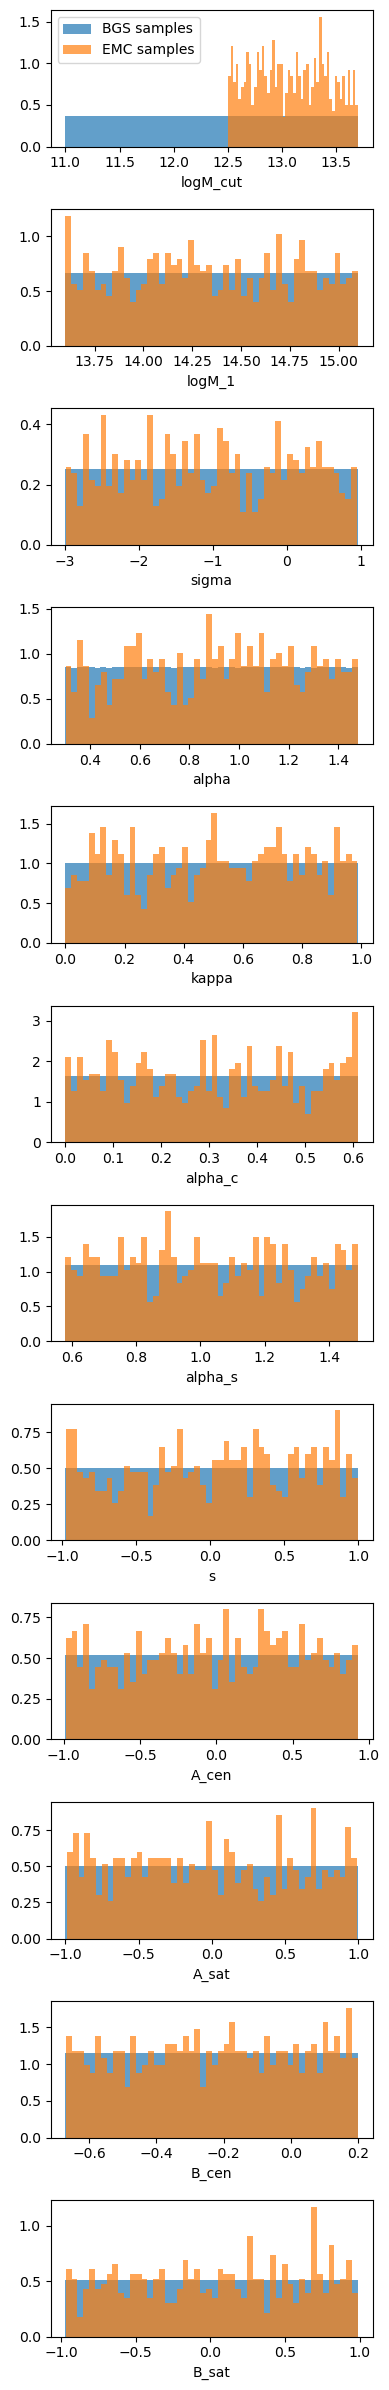

In [ ]:
plotter = HODPlots()

hod_params_bgs = plotter.load_hod_params(str(parameters_dir / 'hod_params'), 'Bouchard25_c*.csv')
hod_params_bgs = np.concatenate([hod_params_bgs[key] for key in sorted(hod_params_bgs.keys())])

hod_params_emc = plotter.load_hod_params('/pscratch/sd/e/epaillas/emc/hod_params/yuan23/cosmo_split/', 'hod_params_yuan23_c*.csv')
hod_params_emc = np.concatenate([hod_params_emc[key] for key in sorted(hod_params_emc.keys())])

fig, ax = plotter.plot_histogram(
    hods = [hod_params_bgs, hod_params_emc], 
    parameters=hod_params_bgs.dtype.names, 
    labels=['BGS samples', 'EMC samples'], 
    bins=50, 
    alpha=0.7, 
    density=True,
)
ax[0].legend()
fig.tight_layout()

#### Compare cosmologies for BGS

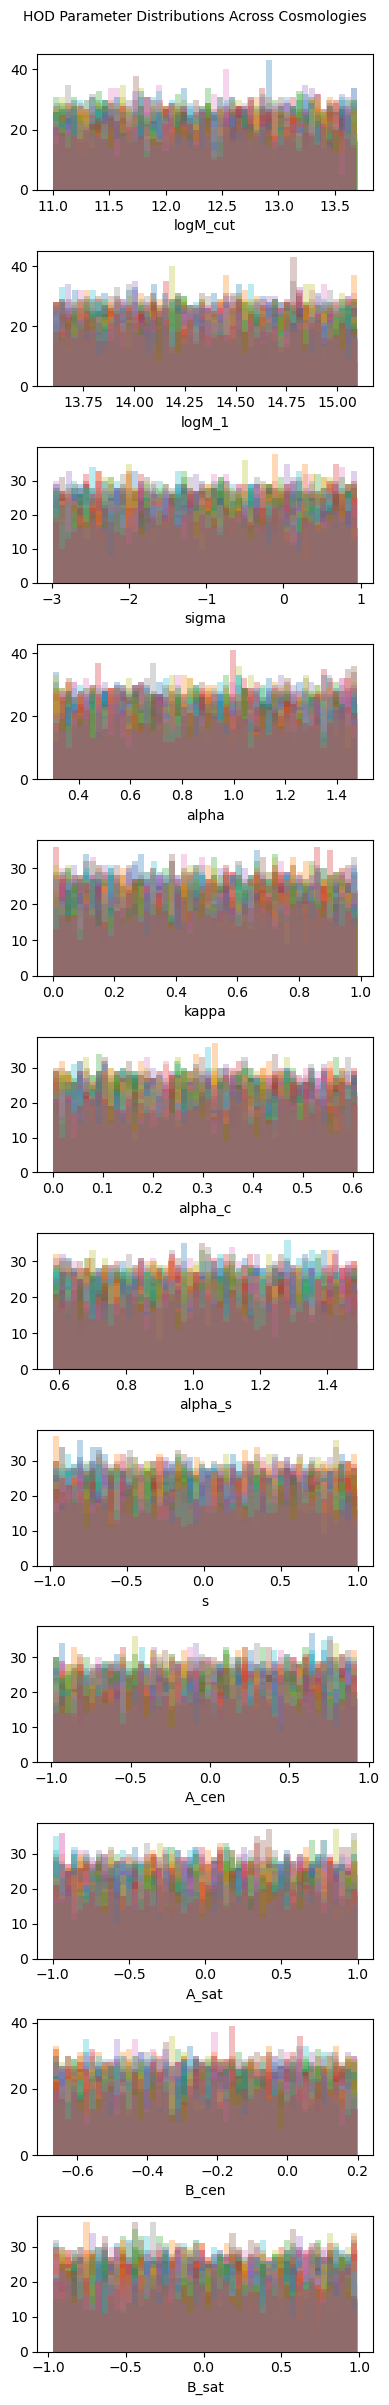

In [ ]:
plotter = HODPlots()

hod_params_cosmo = plotter.load_hod_params(str(parameters_dir / 'hod_params'), 'Bouchard25_c*.csv')
hod_params_cosmo = [hod_params_cosmo[f'c{c:03d}'] for c in sorted(cosmo_list)]

fig, ax = plotter.plot_histogram(
    hods = hod_params_cosmo, 
    parameters = hod_params_cosmo[0].dtype.names, 
    labels = [f'c{c:03d}' for c in sorted(cosmo_list)],
    bins = 50, 
    alpha = 0.3, 
    # density = True,
)
# ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', title='Cosmology')
fig.suptitle('HOD Parameter Distributions Across Cosmologies', fontsize=10, y=1.00)
fig.tight_layout()

#### Check Cosmological parameters

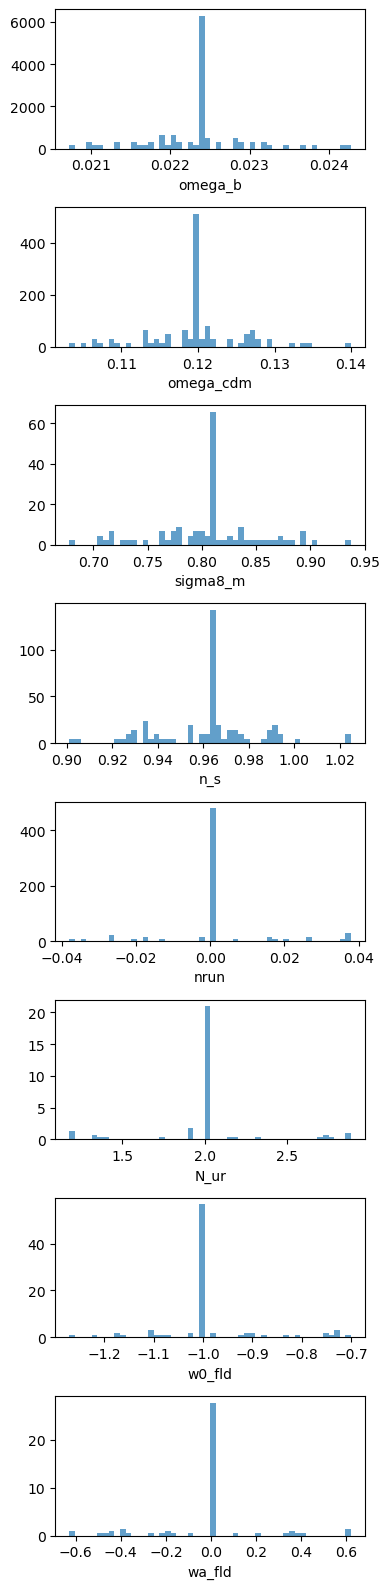

In [ ]:
plotter = HODPlots()

cosmo_params = plotter.load_hod_params(str(parameters_dir / 'cosmo+hod_params'), 'AbacusSummit_c*.csv')
cosmo_params = np.concatenate([cosmo_params[key] for key in sorted(cosmo_params.keys())])

fig, ax = plotter.plot_histogram(
    hods = [cosmo_params], 
    parameters=cosmo_params.dtype.names[:8], 
    bins=50, 
    alpha=0.7, 
    density=True
)
fig.tight_layout()

#### Plot all c000 HOD parameters vs HOD parameters returning nbar=0.01 for c000

Imposing a physical constraint on the sampled HOD space through a density cut.

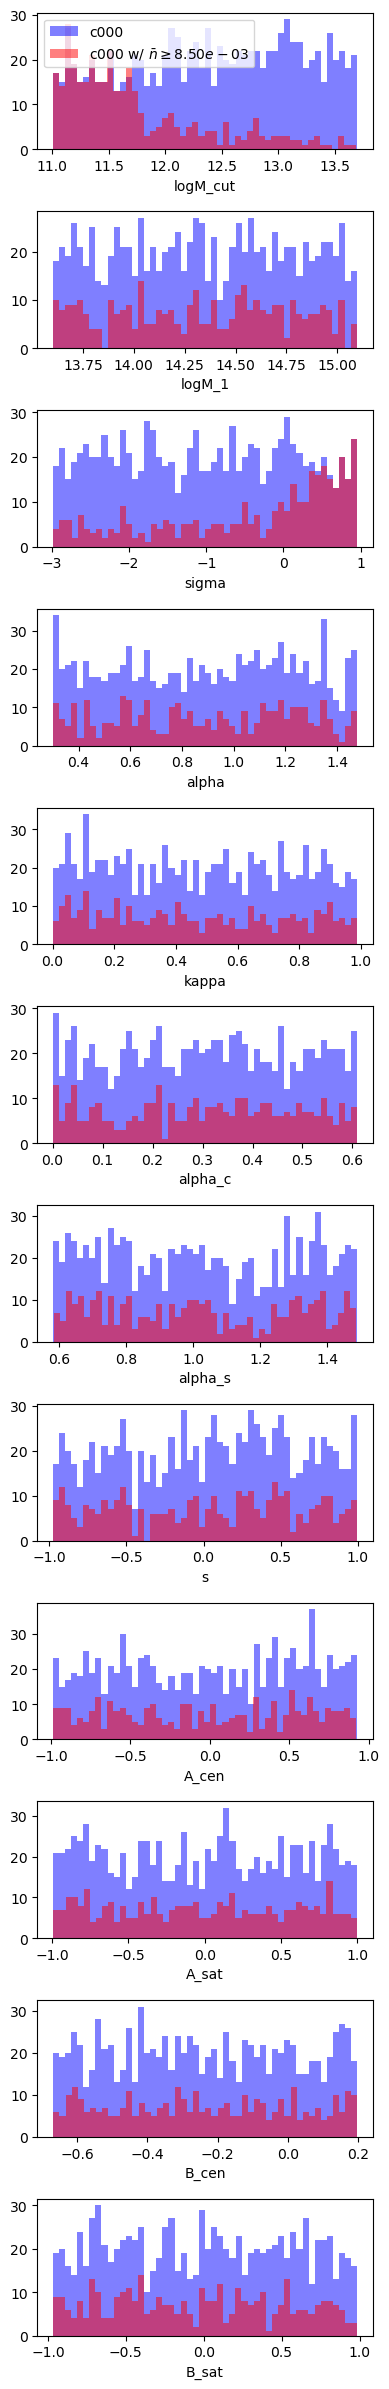

In [33]:
density_dir = bgs_nofilter_dir
density_fns = sorted(density_dir.glob('hod*/density.npy'))
densities = [np.load(fn) for fn in density_fns]
target_density = 8.5e-3 # Mpc^-3 h^3
density_idx = [int(fn.stem.lstrip('hod')) for i, fn in enumerate(sorted(density_dir.glob('hod*'))) if densities[i] >= target_density]

plotter = HODPlots()

hod_params_c000 = plotter.load_hod_params(parameters_dir / 'hod_params', 'Bouchard25_c*.csv')['c000']
hod_params_density = hod_params_c000[density_idx]

fig, ax = plotter.plot_histogram(
    hods = [hod_params_c000, hod_params_density], 
    parameters = hod_params_c000.dtype.names, 
    labels = ['c000', rf'c000 w/ $\bar{{n}} \geq {target_density:.2e}$'],
    colors = ['blue', 'red'],
    bins = 50, 
    alpha = 0.5, 
    # density = True,
)
ax[0].legend()
fig.tight_layout()

## 2- Processed mocks

Count the number of HOD folders in each cosmology folder.

Then, count the number of statistic files computed (marginalized over HOD) for each cosmology.

In [47]:
def get_hod_folders(dir: Path, cosmologies: list[int], phases: list[int], seeds: list[int], sim_type: str) -> dict:
    hod_fns = {}
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                f = Path(measurements_dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}'
                fn_list = sorted(f.glob('hod*'))
                hod_fns[(cosmology, phase, seed)] = fn_list
    return hod_fns

#### Base boxes hod counts

In [70]:
hod_fns = get_hod_folders(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

expected_number = 100
warn_empty = True

for cosmology in cosmo_list:
    count = len(hod_fns[(cosmology, 0, 0)])
    if count < expected_number and count > 0:
        last_hod = hod_fns[(cosmology, 0, 0)][-1].stem.lstrip('hod')
        print(f'Cosmology c{cosmology:03d} has {count} HOD folders (expected {expected_number}). Last HOD: {last_hod}')
    elif count == 0 and warn_empty:
        print(f'Cosmology c{cosmology:03d} has no HOD folders.')

Cosmology c000 has 2 HOD folders (expected 100). Last HOD: 008
Cosmology c001 has 1 HOD folders (expected 100). Last HOD: 001
Cosmology c002 has no HOD folders.
Cosmology c003 has no HOD folders.
Cosmology c004 has no HOD folders.
Cosmology c013 has no HOD folders.
Cosmology c100 has no HOD folders.
Cosmology c101 has no HOD folders.
Cosmology c102 has no HOD folders.
Cosmology c103 has no HOD folders.
Cosmology c104 has no HOD folders.
Cosmology c105 has no HOD folders.
Cosmology c106 has no HOD folders.
Cosmology c107 has no HOD folders.
Cosmology c108 has no HOD folders.
Cosmology c109 has no HOD folders.
Cosmology c110 has no HOD folders.
Cosmology c111 has no HOD folders.
Cosmology c112 has no HOD folders.
Cosmology c113 has no HOD folders.
Cosmology c114 has no HOD folders.
Cosmology c115 has no HOD folders.
Cosmology c116 has no HOD folders.
Cosmology c117 has no HOD folders.
Cosmology c118 has no HOD folders.
Cosmology c119 has no HOD folders.
Cosmology c120 has no HOD folders.

In [71]:
statistics = [
    'density',
    'tpxf_los_x',
    'tpxf_los_y',
    'tpxf_los_z',
    'quantile_data_correlation_los_x',
    'quantile_data_correlation_los_y',
    'quantile_data_correlation_los_z',
    'quantile_correlation_los_x',
    'quantile_correlation_los_y',
    'quantile_correlation_los_z',
]
expected_number = 100
warn_empty = False

stat_count = {statistic: {} for statistic in statistics}

for cosmology in cosmo_list:
    for statistic in statistics:
        count = 0
        for fn in hod_fns[(cosmology, 0, 0)]:
                stat_fns = sorted(fn.glob(f'{statistic}*.npy'))
                count += len(stat_fns)
        
        stat_count[statistic][cosmology] = count
        if count < expected_number and count > 0:
            print(f'Cosmology c{cosmology:03d} has {count} {statistic} files (expected {expected_number}).')
        elif count == 0 and warn_empty:
            # print(f'Cosmology c{cosmology:03d} has no {statistic} files.')
            pass

Cosmology c000 has 2 density files (expected 100).
Cosmology c000 has 1 quantile_data_correlation_los_x files (expected 100).
Cosmology c000 has 1 quantile_data_correlation_los_y files (expected 100).
Cosmology c000 has 1 quantile_data_correlation_los_z files (expected 100).
Cosmology c000 has 1 quantile_correlation_los_x files (expected 100).
Cosmology c000 has 1 quantile_correlation_los_y files (expected 100).
Cosmology c000 has 1 quantile_correlation_los_z files (expected 100).
Cosmology c001 has 1 density files (expected 100).


## 3- Measurements

### 3.1- Density

In [10]:
def get_densities(dir: Path|str, cosmologies: list, phases: list, seeds: list, sim_type: str) -> np.ndarray:
    """Get densities from all the HOD realizations."""
    densities = []
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                fn_list = (Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}').glob('hod*/density.npy')
                for fn in fn_list:
                    d = np.load(fn, allow_pickle=True).item()
                    densities.append(d)
    densities = np.array(densities)
    return densities

#### Base boxes density histogram

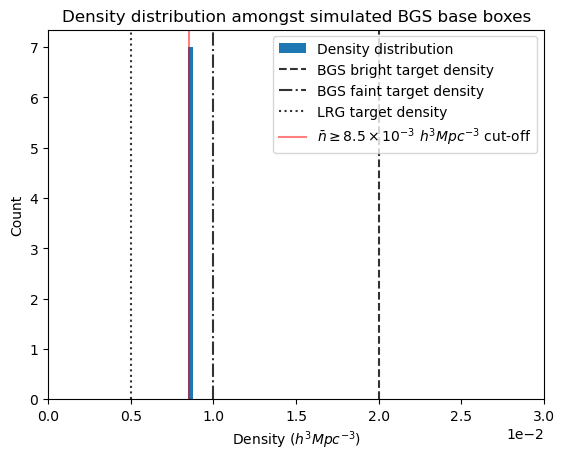

In [11]:
densities = get_densities(dir=measurements_dir, cosmologies=cosmo_list, phases=[0], seeds=[0], sim_type='base')

bins = np.linspace(0, 0.03, 100)
plt.hist(densities, bins=bins, label='Density distribution')
plt.axvline(2e-2, color='k', linestyle='--', alpha=0.8, label='BGS bright target density')
plt.axvline(1e-2, color='k', linestyle='-.', alpha=0.8, label='BGS faint target density')
plt.axvline(5e-3, color='k', linestyle='dotted', alpha=0.8, label='LRG target density')

plt.axvline(8.5e-3, color='r', linestyle='solid', alpha=0.5, label=r'$\bar{n} \geq 8.5 \times 10^{-3}\ h^3 Mpc^{-3}$ cut-off')

plt.xlim(0, 0.03)
plt.legend()
plt.xlabel(r'Density ($h^3 Mpc^{-3}$)')
plt.ylabel('Count')
plt.title('Density distribution amongst simulated BGS base boxes')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0));

#### Small boxes density histogram

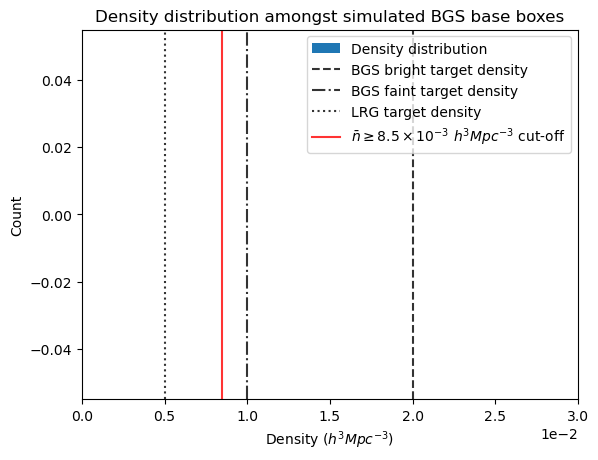

In [39]:
densities = get_densities(dir=measurements_dir, cosmologies=[0], phases=[0], seeds=[0], sim_type='small')

bins = np.linspace(0, 0.03, 50)
plt.hist(densities, bins=bins, label='Density distribution')
plt.axvline(2e-2, color='k', linestyle='--', alpha=0.8, label='BGS bright target density')
plt.axvline(1e-2, color='k', linestyle='-.', alpha=0.8, label='BGS faint target density')
plt.axvline(5e-3, color='k', linestyle='dotted', alpha=0.8, label='LRG target density')

plt.axvline(8.5e-3, color='r', linestyle='solid', alpha=0.8, label=r'$\bar{n} \geq 8.5 \times 10^{-3}\ h^3 Mpc^{-3}$ cut-off')

plt.xlim(0, 0.03)
plt.legend()
plt.xlabel(r'Density ($h^3 Mpc^{-3}$)')
plt.ylabel('Count')
plt.title('Density distribution amongst simulated BGS small boxes')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0));

### 3.2- Two-point correlation function

In [4]:
from pycorr import TwoPointEstimator
def get_tpcf(dir: Path|str, cosmologies: list, phases: list, seeds: list, sim_type: str) -> np.ndarray:
    """Get two-point correlation functions from all the HOD realizations."""
    tpcfs = []
    for cosmology in cosmologies:
        for phase in phases:
            for seed in seeds:
                dir_ = Path(dir) / sim_type / f'c{cosmology:03d}_ph{phase:03d}' / f'seed{seed}'
                # Get all the HOD realizations
                hod_folders = sorted(dir_.glob('hod*'))
                for hod in hod_folders:
                    fn_list = sorted(hod.glob('tpcf_los_*.npy'))
                    tmp_cf = None
                    for fn in fn_list:
                        d = TwoPointEstimator.load(fn)
                        if tmp_cf is None:
                            tmp_cf = d
                        else:
                            tmp_cf = d.concatenate_x(d, tmp_cf)
                    if tmp_cf is not None:
                        tpcfs.append(tmp_cf)
    tpcfs = np.array(tpcfs)
    return tpcfs

In [18]:
tmp_dir = Path('/pscratch/sd/s/sbouchar/test/bgs_no_ap')

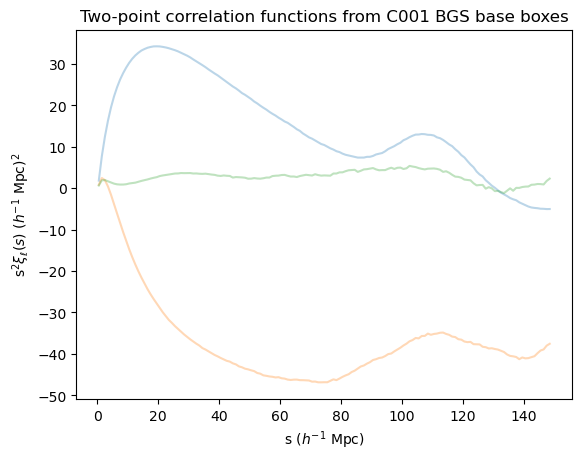

In [24]:
cfs_1 = get_tpcf(dir=tmp_dir, cosmologies=[1], phases=[0], seeds=[0], sim_type='base')
cfs = get_tpcf(dir=measurements_dir, cosmologies=[0], phases=[0], seeds=[0], sim_type='base')

for cf in cfs_1:
    s, poles = cf(ells=[0, 2, 4], return_sep=True)
    plt.plot(s, poles[0]*s**2, alpha=0.3, c='C0')
    plt.plot(s, poles[1]*s**2, alpha=0.3, c='C1')
    plt.plot(s, poles[2]*s**2, alpha=0.3, c='C2')

plt.xlabel(r's ($h^{-1}$ Mpc)')
plt.ylabel(r's$^2 \xi_{\ell}(s)$ ($h^{-1}$ Mpc)$^2$')
plt.title('Two-point correlation functions from C001 BGS base boxes');

### 3.3- Density split